In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("D:/Data Analyst/project/Python_Netflix_Content_Analysis/dataset/netflix_titles.csv")

# Data Cleanup
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['rating'] = df['rating'].fillna("Unknown")

In [2]:
# Extract duration values
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype('Int64')
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z])')

In [3]:
# Movie
movie_dur = df[(df['type'] == 'Movie') & (df['duration_int'].notna())]
movie_dur = movie_dur[(movie_dur['duration_int'] > 30) & (movie_dur['duration_int'] < 250)]

# TV Show seasons distribution
shows_dur = df[(df['type'] == 'TV Show') & (df['duration_int'].notna())]
shows_dur = shows_dur['duration_int'].value_counts().sort_index().head(15).to_frame()

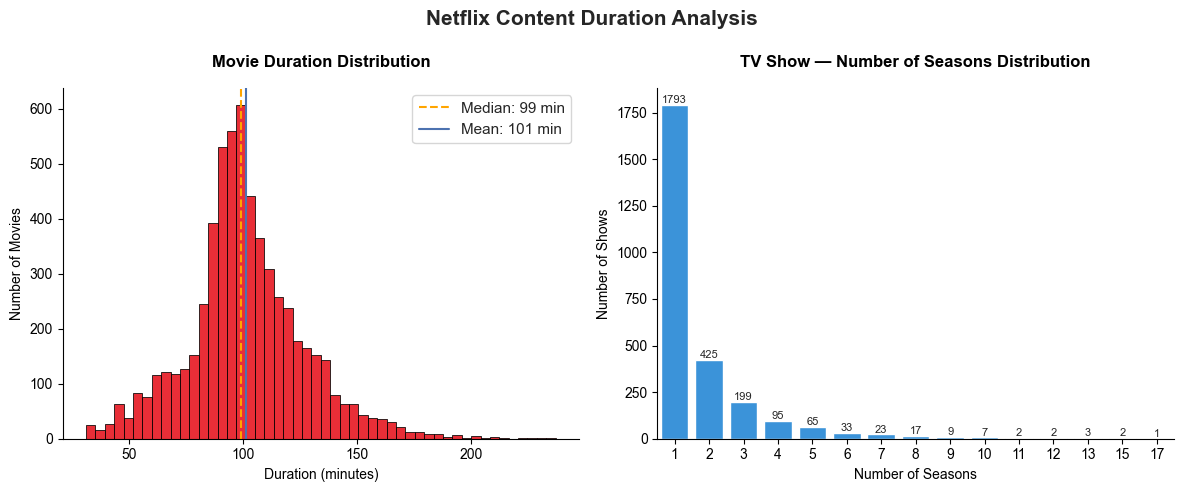

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.set_theme(style='ticks')
sns.despine()

median_val = movie_dur['duration_int'].median()
mean_val = movie_dur['duration_int'].mean()

# Movie Duration Distribution
sns.histplot(data=movie_dur['duration_int'], ax=ax[0], color='#E50914', bins=50, edgecolor='black', alpha=0.85)

median_line = ax[0].axvline(median_val, linestyle='--', color='orange')
mean_line = ax[0].axvline(mean_val, linestyle='-', color='b')

ax[0].legend([median_line, mean_line], [f'Median: {median_val:.0f} min', f'Mean: {mean_val:.0f} min'])

ax[0].set_title('Movie Duration Distribution', fontweight='bold', pad=15)
ax[0].set_xlabel('Duration (minutes)')
ax[0].set_ylabel('Number of Movies')

# TV Show seasons distribution
sns.barplot(data=shows_dur, x='duration_int', y='count', ax=ax[1], color='#2196F3')
ax[1].set_title('TV Show — Number of Seasons Distribution', fontweight='bold', pad=15)
ax[1].set_xlabel('Number of Seasons')
ax[1].set_ylabel('Number of Shows')

# Add value labels
for i, v in enumerate(shows_dur['count']):
    ax[1].text(
        i,            # x position (bar index)
        v + 10,       # y position (slightly above bar)
        f'{v:.0f}',   # label text
        ha='center',
        fontsize=8
    )

plt.suptitle('Netflix Content Duration Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()